<a href="https://colab.research.google.com/github/Kai856/wildlife-classification-/blob/main/categorical_animals_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow import keras
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

import numpy as np
import os
import cv2
from glob import glob
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
# Downloading all data
!wget https://www.crcv.ucf.edu/datasets/fwctd/Part1.zip --no-check-certificate
!wget https://www.crcv.ucf.edu/datasets/fwctd/Part2.zip --no-check-certificate
!wget https://www.crcv.ucf.edu/data1/dataset/fwctd/Part3.zip --no-check-certificate
!wget https://www.crcv.ucf.edu/datasets/fwctd/Part4.zip --no-check-certificate
!wget https://www.crcv.ucf.edu/datasets/fwctd/Part5.zip --no-check-certificate

--2024-08-19 22:56:07--  https://www.crcv.ucf.edu/datasets/fwctd/Part1.zip
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 11296186055 (11G) [application/zip]
Saving to: ‘Part1.zip’

Part1.zip           100%[===================>]  10.52G  75.7MB/s    in 2m 28s  

2024-08-19 22:58:35 (72.9 MB/s) - ‘Part1.zip’ saved [11296186055/11296186055]

--2024-08-19 22:58:36--  https://www.crcv.ucf.edu/datasets/fwctd/Part2.zip
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 19479734346 (18G) [application/zip]
Saving to: ‘Part2.zip’

Part2.zip           100%[===================>]  18.14G  79

In [ ]:
# Unzipping all data
!unzip Part1.zip
!unzip Part2.zip
!unzip Part3.zip
!unzip Part4.zip
!unzip Part5.zip

unzip:  cannot find or open Part1.zip, Part1.zip.zip or Part1.zip.ZIP.
unzip:  cannot find or open Part2.zip, Part2.zip.zip or Part2.zip.ZIP.
unzip:  cannot find or open Part3.zip, Part3.zip.zip or Part3.zip.ZIP.
unzip:  cannot find or open Part4.zip, Part4.zip.zip or Part4.zip.ZIP.
unzip:  cannot find or open Part5.zip, Part5.zip.zip or Part5.zip.ZIP.


In [ ]:
# Path to dataset
dataset_path = "/content/"
# Define image dimensions and batch size
img_height, img_width = 224, 224
batch_size = 64

In [ ]:
# Load the training dataset, 70% training
train_ds = tf.keras.preprocessing.image_dataset_from_directory (
    dataset_path,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)
# Load the validation dataset, 20% validation
val_ds = tf.keras.preprocessing.image_dataset_from_directory (
    dataset_path,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

Found 104495 files belonging to 22 classes.
Using 73147 files for training.
Found 104495 files belonging to 22 classes.
Using 31348 files for validation.


In [ ]:
# Creating testing dataset
val_batches = int((2/3) * len(val_ds))  # 20% of the original data
test_ds = val_ds.skip(val_batches)  # Skip first 2/3 for test
val_ds = val_ds.take(val_batches)    # Take first 2/3 for validation

In [ ]:
# Use ResNet152V2 as base model
base_model = tf.keras.applications.ResNet152V2(
    include_top=False,
    weights="imagenet",
    input_shape=(img_height, img_width, 3)
)
# Freeze the layers of the base model, we only want to train additional layer
# base_model.trainable = False

In [ ]:
# Get number of animal labels
num_animals = len(train_ds.class_names)
num_animals

22

In [ ]:
# Create a new model using ResNet152V2 architecture
model = Sequential([
    base_model, #Weight will not change with training
    # Flatten(), #flattens the input 224 x 224 image matrix to 50176 dimension vector
    # Dense(384, activation='relu'), #add another layer that IS trainable
    GlobalAveragePooling2D(),
    Dense(num_animals, activation='softmax')  #categorical output layer
])
# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-3), #Learning rate according to paper
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train model
epochs = 10
history  = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

Epoch 1/10
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 836s 604ms/step - accuracy: 0.7591 - loss: 0.8214 - val_accuracy: 0.8387 - val_loss: 0.5525
Epoch 2/10
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 623s 545ms/step - accuracy: 0.9057 - loss: 0.3116 - val_accuracy: 0.8943 - val_loss: 0.3613
Epoch 3/10
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 632s 553ms/step - accuracy: 0.9408 - loss: 0.1917 - val_accuracy: 0.9281 - val_loss: 0.2431
Epoch 4/10
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 638s 558ms/step - accuracy: 0.9592 - loss: 0.1300 - val_accuracy: 0.8978 - val_loss: 0.3415
Epoch 5/10
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 636s 556ms/step - accuracy: 0.9714 - loss: 0.0891 - val_accuracy: 0.9436 - val_loss: 0.2024
Epoch 6/10
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 657s 574ms/step - accuracy: 0.9774 - loss: 0.0710 - val_accuracy: 0.9476 - val_loss: 0.1930
Epoch 7/10
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 668s 584ms/step - accuracy: 0.9829 - loss: 0.0553 - val_accuracy: 0.9359 - val_loss: 0.2170
Epoch 8/10
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 674s 590ms/step - ac

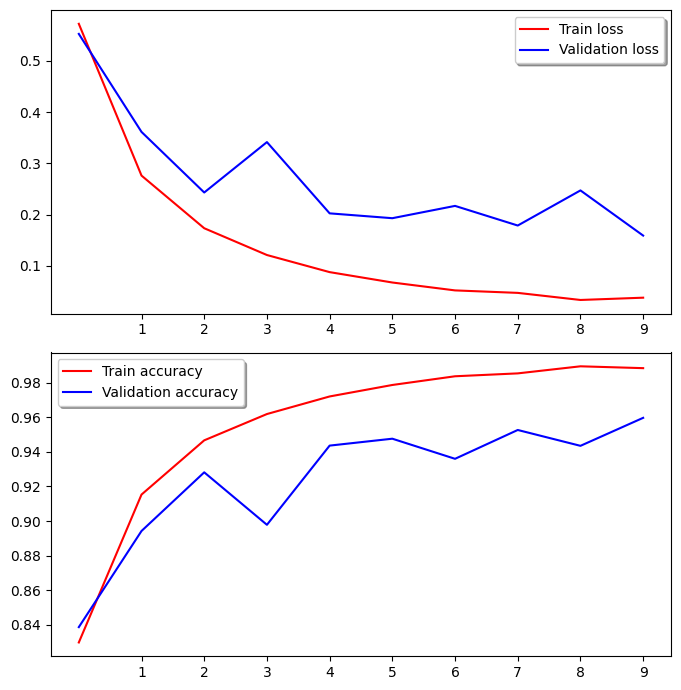

In [ ]:
# Plot accuracy and loss curves
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7))

ax1.plot(history.history['loss'], color='r', label="Train loss")
ax1.plot(history.history['val_loss'], color='b', label="Validation loss")
ax1.set_xticks(np.arange(1, epochs, 1))
legend = ax1.legend(loc='best', shadow=True)

ax2.plot(history.history['accuracy'], color='r', label="Train accuracy")
ax2.plot(history.history['val_accuracy'], color='b',label="Validation accuracy")
ax2.set_xticks(np.arange(1, epochs, 1))
legend = ax2.legend(loc='best', shadow=True)

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

164/164 ━━━━━━━━━━━━━━━━━━━━ 78s 163ms/step - accuracy: 0.9591 - loss: 0.1568


In [ ]:
print(f"Test accuracy: {test_accuracy}")
print(f"Test loss: {test_loss}")

Test accuracy: 0.9602251052856445
Test loss: 0.15750086307525635


In [ ]:
# Save the model
model.save("animal_classification.keras")

In [ ]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet152v2 (Functional)             │ (None, 7, 7, 2048)          │      58,331,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 22)                  │          45,078 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 174,842,692 (666.97 MB)

 Trainable params: 58,232,982 (222.14 MB)

 Non-trainable params: 143,744 (561.50 KB)

 Optimizer params: 116,465,966 (444.28 MB)